In [ ]:
%cd /content/drive/MyDrive/Deep Learning/fruit-detection-project
!ls

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random

In [ ]:
# From ObjectDetection.ipynb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PredictionHead(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(PredictionHead, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(in_channels // 2),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 2, in_channels // 4, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
        )
        self.box_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 4, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )
        self.classifier = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, num_classes, kernel_size=3, padding=1),
        )
        self.objectness_predictor = nn.Sequential(
            nn.Conv2d(in_channels // 4, in_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels // 4),
            nn.LeakyReLU(negative_slope=0.1),
            nn.Conv2d(in_channels // 4, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        cls_logits = self.classifier(x)
        bbox_pred = self.box_predictor(x)
        objectness_pred = self.objectness_predictor(x)
        grid_size = x.shape[-1]
        grid_y, grid_x = torch.meshgrid(
            torch.arange(grid_size, device=x.device), 
            torch.arange(grid_size, device=x.device), indexing="ij"
        )
        cx = (bbox_pred[:, 0, :, :] + grid_x) / grid_size
        cy = (bbox_pred[:, 1, :, :] + grid_y) / grid_size
        w, h = bbox_pred[:, 2, :, :], bbox_pred[:, 3, :, :]
        return cls_logits, torch.stack([cx, cy, w, h], dim=1), objectness_pred

class ObjectDetectorMultiScale(nn.Module):
    def __init__(self, n_classes):
        super(ObjectDetectorMultiScale, self).__init__()
        backbone = torchvision.models.resnet18(weights=None)
        self.backbone = nn.Sequential(*list(backbone.children())[:-3]) # Up to Layer 3 (256 channels)
        self.block_1 = nn.Sequential(*list(backbone.children())[-3])  # Layer 4 (512 channels)
        self.prediction_head = PredictionHead(512, n_classes)
        self.prediction_head_2 = PredictionHead(256, n_classes)

    def forward(self, x):
        features = self.backbone(x)
        y_ = self.block_1(features)
        cls1, box1, obj1 = self.prediction_head(y_)
        cls2, box2, obj2 = self.prediction_head_2(features)
        
        def flatten(t): return t.flatten(2, 3).permute(0, 2, 1)
        return {
            "pred_logits": torch.cat([flatten(cls1), flatten(cls2)], dim=1),
            "pred_boxes": torch.cat([flatten(box1), flatten(box2)], dim=1),
            "pred_objectness": torch.cat([flatten(obj1), flatten(obj2)], dim=1)
        }


In [34]:
detector_weights = 'fruit-detection-challenge/weights/fruit_detector.pth'
classifier_weights = 'fruit-detection-challenge/weights/fruit_classifier.pth'

num_classes_detector = 1
num_classes_classifier = 4 

class_names = ['apple', 'banana', 'orange', 'pear'] 

detector = ObjectDetectorMultiScale(n_classes=num_classes_detector)
detector.load_state_dict(torch.load(detector_weights, map_location=device))
detector.to(device).eval()

classifier = torchvision.models.resnet50(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, num_classes_classifier)
classifier.load_state_dict(torch.load(classifier_weights, map_location=device))
classifier.to(device).eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
det_transform = ToTensor()

# For classifiers
clf_transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
def detect_and_classify(image_path, conf_threshold=0.4, nms_threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    
    # Detection. Detector was trained on 256x256, so we resize input image
    input_img = image.resize((256, 256))
    img_tensor = det_transform(input_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = detector(img_tensor)
    
    boxes = out["pred_boxes"][0] 
    objectness = out["pred_objectness"][0].squeeze()
    
    keep_idx = objectness > conf_threshold
    if keep_idx.sum() == 0: return []
    
    boxes, scores = boxes[keep_idx], objectness[keep_idx]

    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = (cx - w/2) * width
    y1 = (cy - h/2) * height
    x2 = (cx + w/2) * width
    y2 = (cy + h/2) * height
    pixel_boxes = torch.stack([x1, y1, x2, y2], dim=1)
    
    # Apply NMS
    nms_idx = torchvision.ops.nms(pixel_boxes, scores, nms_threshold)
    final_boxes = pixel_boxes[nms_idx]
    final_scores = scores[nms_idx]

    # Classify
    results = []
    for box, score in zip(final_boxes, final_scores):
        ix1, iy1, ix2, iy2 = box.int().tolist()
        
        crop = image.crop((max(0, ix1), max(0, iy1), min(width, ix2), min(height, iy2)))
        crop_tensor = clf_transform(crop).unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_logits = classifier(crop_tensor)
        class_id = class_logits.argmax(dim=1).item()

        results.append({
            "box": [ix1, iy1, ix2, iy2],
            "confidence": score.item(),
            "class_id": class_id,
        })

    return results

In [25]:
def plot_results(image_path, predictions, class_names):
    img = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)
    for res in predictions:
        x1, y1, x2, y2 = res["box"]
        conf = res["confidence"]
        class_id = res["class_id"]
        name = class_names[class_id] if class_id < len(class_names) else f"ID:{class_id}"

        
        rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, 
        linewidth=3, edgecolor='lime', facecolor='none'
            )
        ax.add_patch(rect)

            # Draw label
        label_text = f"{name} ({conf:.2f})"
        plt.text(
        x1, y1 - 10, label_text, 
        color='black', fontweight='bold', fontsize=12,
        bbox=dict(facecolor='lime', alpha=0.7, pad=2)
            )
    plt.axis('off')
    plt.show()

Testing: color_014.png


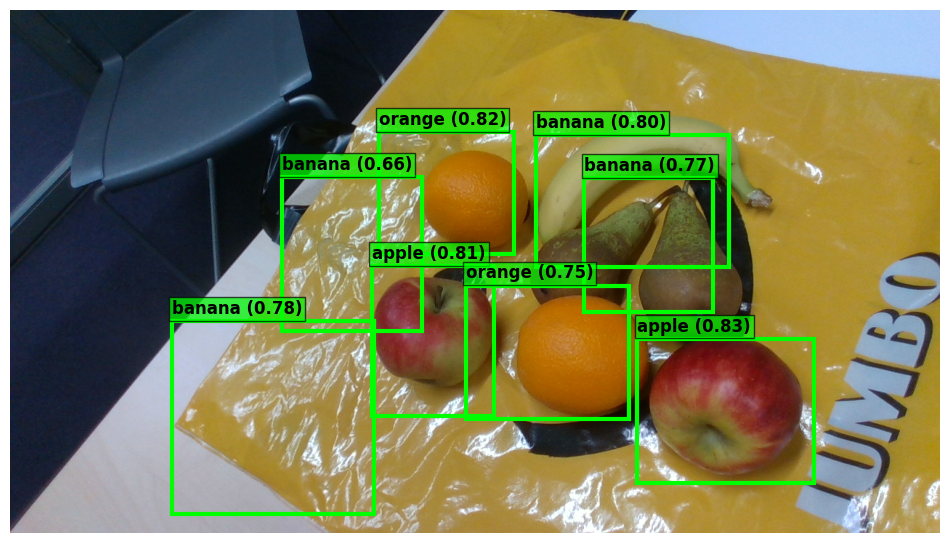

In [32]:
import glob
val_path = '/content/drive/MyDrive/Deep Learning/fruit-detection-project/fruit-detection-challenge/test/'
val_files = glob.glob(val_path + "*.png")
samples = random.sample(val_files, min(1, len(val_files)))
for img_file in samples:
            print(f"Testing: {os.path.basename(img_file)}")
            preds = detect_and_classify(img_file, conf_threshold=0.5, nms_threshold=0.5)
            plot_results(img_file, preds, class_names)

